In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import missingno as msno  # Optional: for visualizing missing data

In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('dataset.csv')

# Display the first few rows of the dataset
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


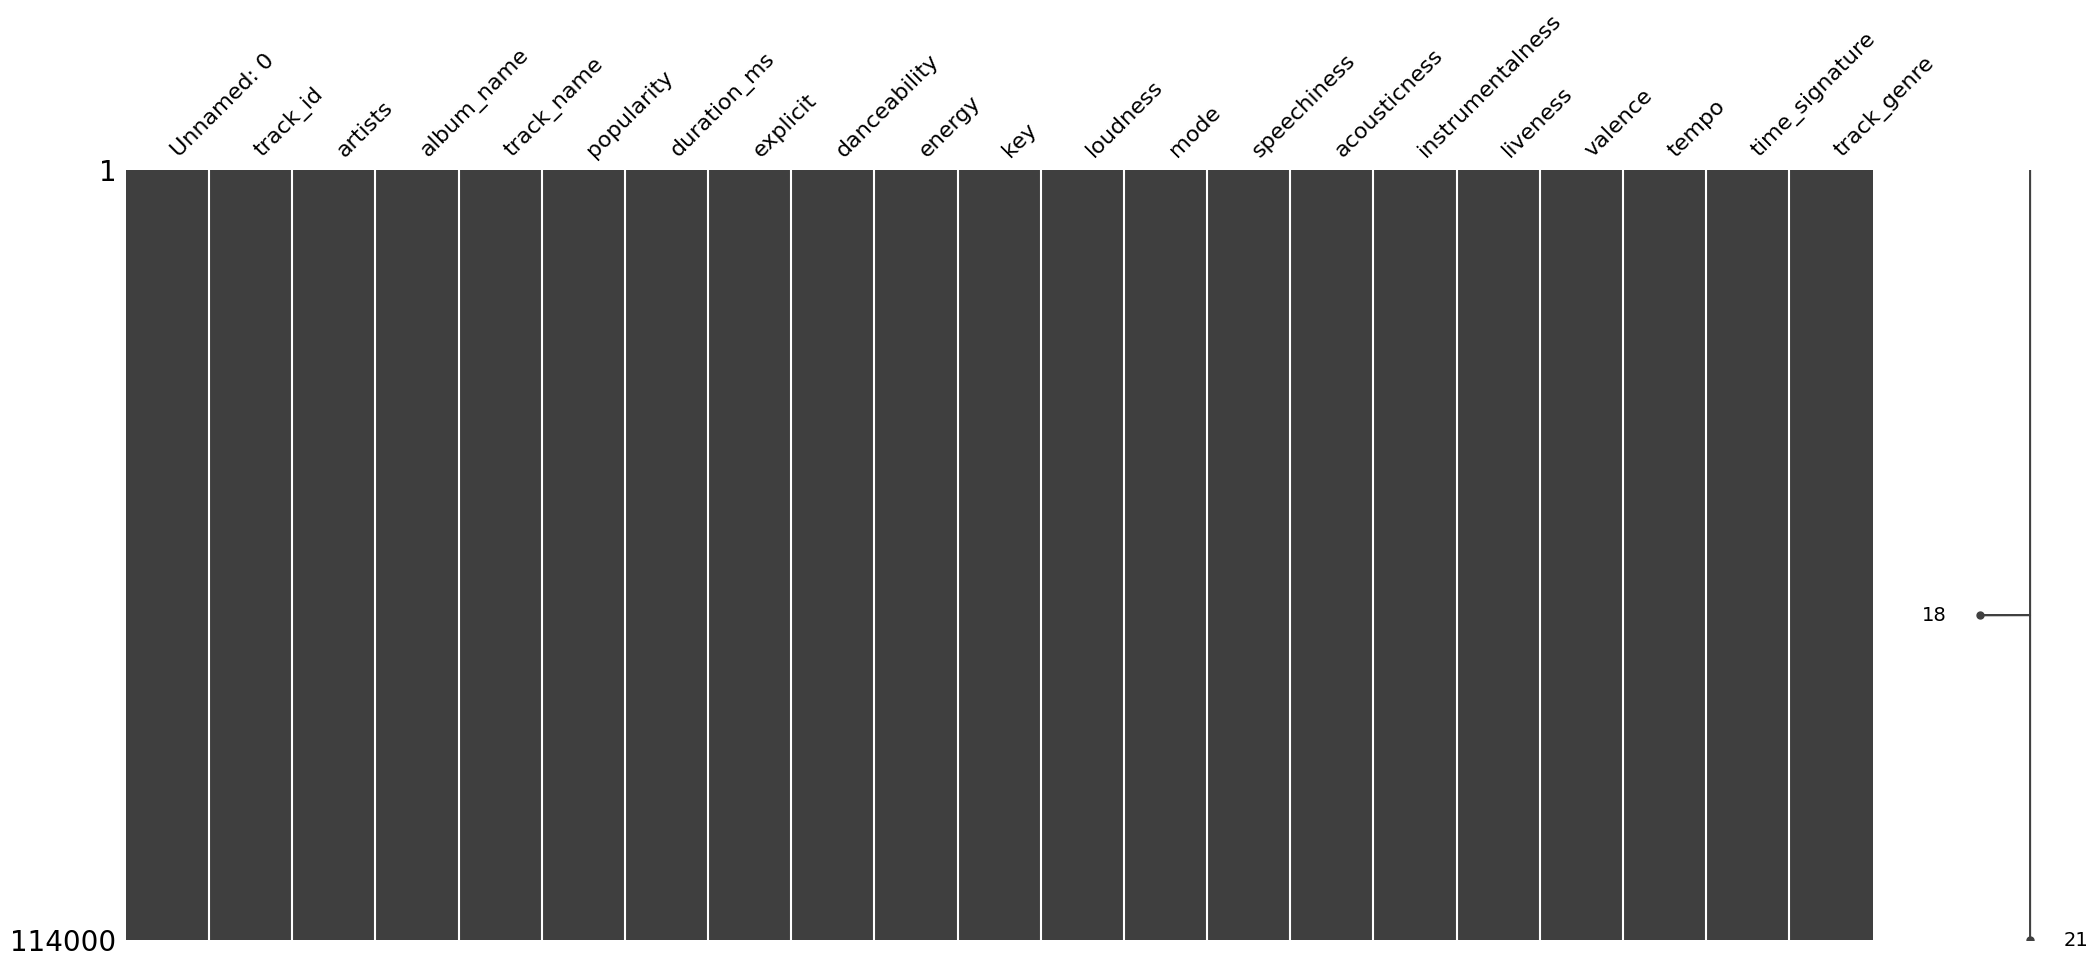

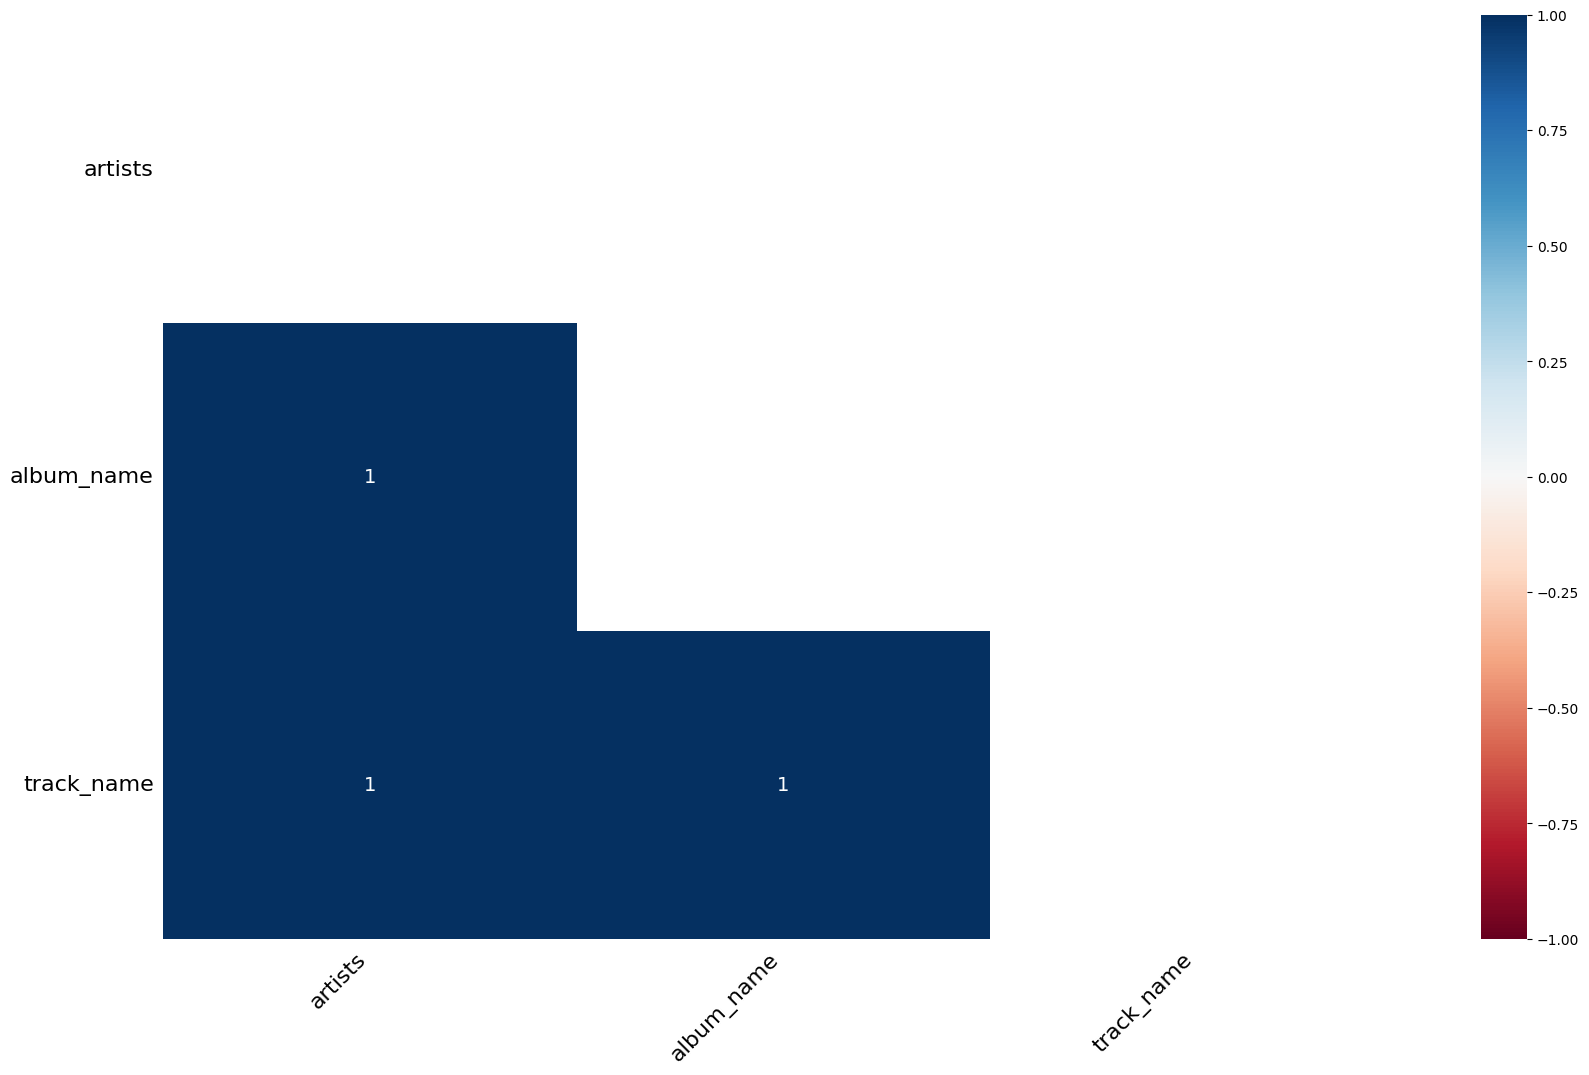

In [3]:
# Visualize missing data (optional)
msno.matrix(df)
msno.heatmap(df)

# Drop rows with missing values
df_cleaned = df.dropna()

# Or, fill missing values with the mean
df_filled = df.fillna(df.mean(numeric_only=True))

In [4]:
from scipy import stats

numeric_cols = df_cleaned.select_dtypes(include='number')

z_scores = np.abs(stats.zscore(numeric_cols))
df_no_outliers = df_cleaned[(z_scores < 3).all(axis=1)]

df_cleaned = df_cleaned.copy()

for col in numeric_cols.columns:
    upper_limit = df_cleaned[col].quantile(0.95)
    df_cleaned[col] = np.where(df_cleaned[col] > upper_limit, upper_limit, df_cleaned[col])

In [5]:
numeric_cols = df_cleaned.select_dtypes(include='number').columns
df_numeric = df_cleaned[numeric_cols]

# Min-Max Scaling
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=numeric_cols)

# Z-score Standardization
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df_numeric), columns=numeric_cols)

In [6]:
# One-hot encoding
df_encoded = pd.get_dummies(df_cleaned, columns=['track_genre', 'key', 'mode'])

print(df_encoded.columns.tolist())  # Result

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre_acoustic', 'track_genre_afrobeat', 'track_genre_alt-rock', 'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime', 'track_genre_black-metal', 'track_genre_bluegrass', 'track_genre_blues', 'track_genre_brazil', 'track_genre_breakbeat', 'track_genre_british', 'track_genre_cantopop', 'track_genre_chicago-house', 'track_genre_children', 'track_genre_chill', 'track_genre_classical', 'track_genre_club', 'track_genre_comedy', 'track_genre_country', 'track_genre_dance', 'track_genre_dancehall', 'track_genre_death-metal', 'track_genre_deep-house', 'track_genre_detroit-techno', 'track_genre_disco', 'track_genre_disney', 'track_genre_drum-and-bass', 'track_genre_dub', 'track_genre_dubstep', 'track_genre_edm', 'track_genre_elect

In [7]:
# Save the cleaned and preprocessed DataFrame to a new CSV file
df_encoded.to_csv('cleaned_preprocessed_data.csv', index=False)

print('Data cleaning and preprocessing complete. File saved as cleaned_preprocessed_data.csv')

Data cleaning and preprocessing complete. File saved as cleaned_preprocessed_data.csv


In [8]:
# WE CAN AUTOMATE IT WITH THIS CODE

def load_data(filepath):
    return pd.read_csv(filepath)

def handle_missing_values(df):
    # Numeric column are mean
    df[df.select_dtypes(include='number').columns] = df.select_dtypes(include='number').fillna(df.mean(numeric_only=True))
    df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').fillna('Unknown')
    return df

def remove_outliers(df):
    numeric_cols = df.select_dtypes(include='number')
    z_scores = np.abs(stats.zscore(numeric_cols))
    return df[(z_scores < 3).all(axis=1)]

def scale_data(df):
    numeric_cols = df.select_dtypes(include='number').columns
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df

def encode_categorical(df, categorical_columns):
    return pd.get_dummies(df, columns=categorical_columns)

def save_data(df, output_filepath):
    df.to_csv(output_filepath, index=False)

df = load_data('dataset.csv')
df = handle_missing_values(df)
df = remove_outliers(df)
df = scale_data(df)
df = encode_categorical(df, ['track_genre', 'key', 'mode'])
save_data(df, 'cleaned_preprocessed_data.csv')

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data check
print(df_cleaned.shape)
print(df_cleaned.dtypes)
print(df_cleaned.describe())

(113999, 21)
Unnamed: 0          float64
track_id             object
artists              object
album_name           object
track_name           object
popularity          float64
duration_ms         float64
explicit               bool
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature      float64
track_genre          object
dtype: object
          Unnamed: 0     popularity    duration_ms   danceability  \
count  113999.000000  113999.000000  113999.000000  113999.000000   
mean    56856.900675      32.907947  222222.230651       0.564506   
std     32677.724103      21.684221   72564.111556       0.169602   
min         0.000000       0.000000    8586.000000       0.000000   
25%     28499.500000      17.000000  174

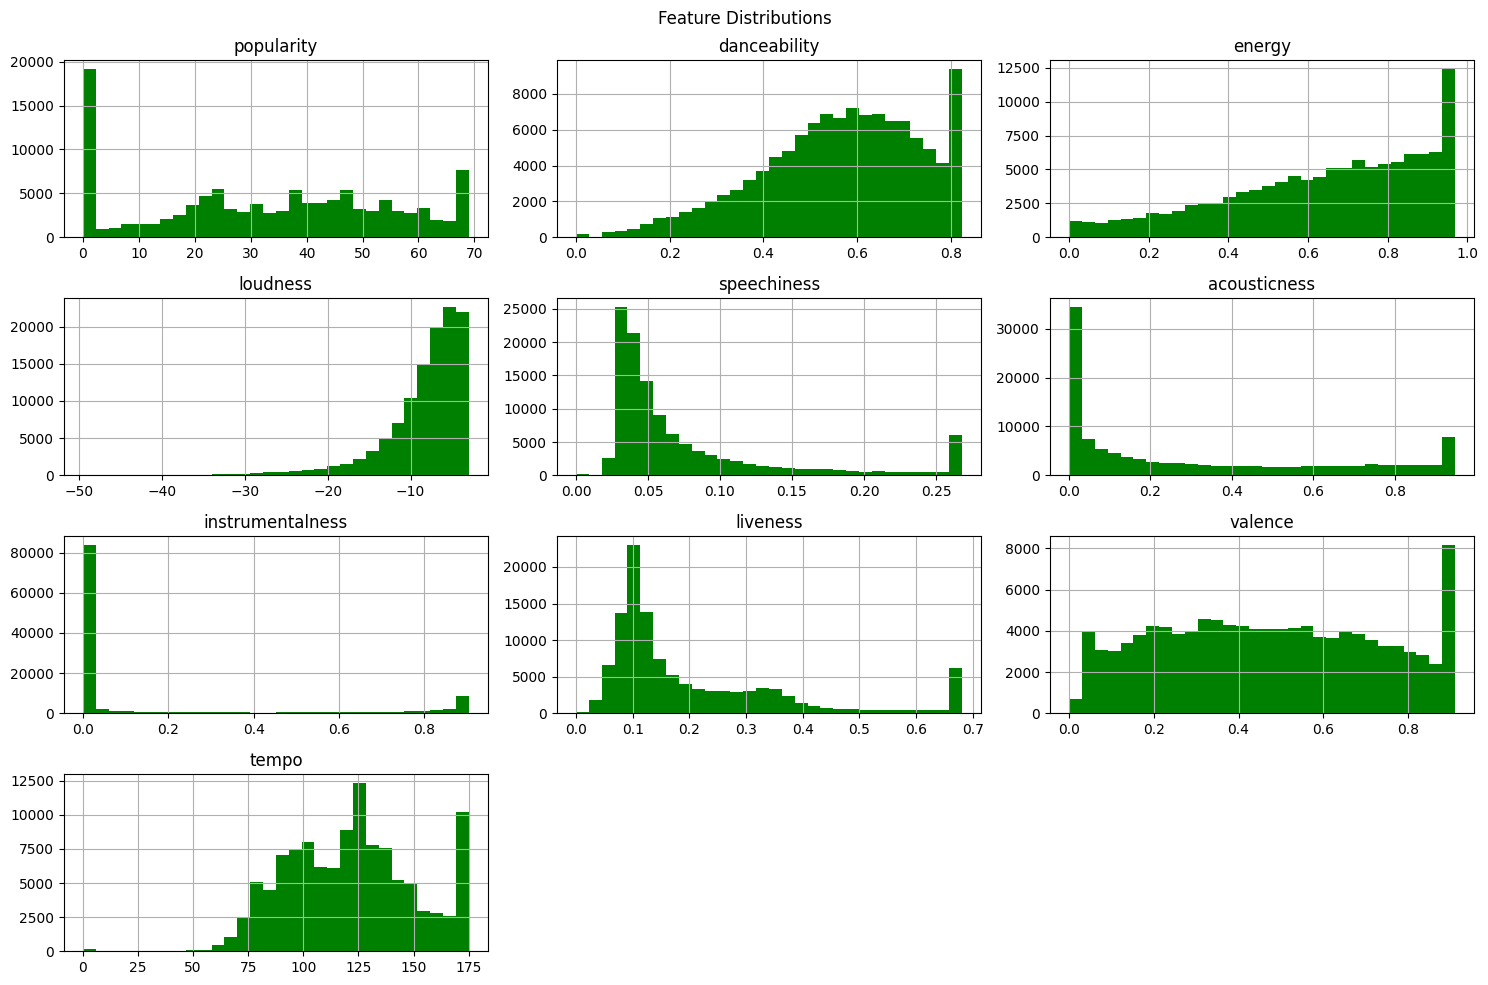

In [10]:
# features
features = ['popularity', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

df_cleaned[features].hist(bins=30, figsize=(15, 10), color='green')
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

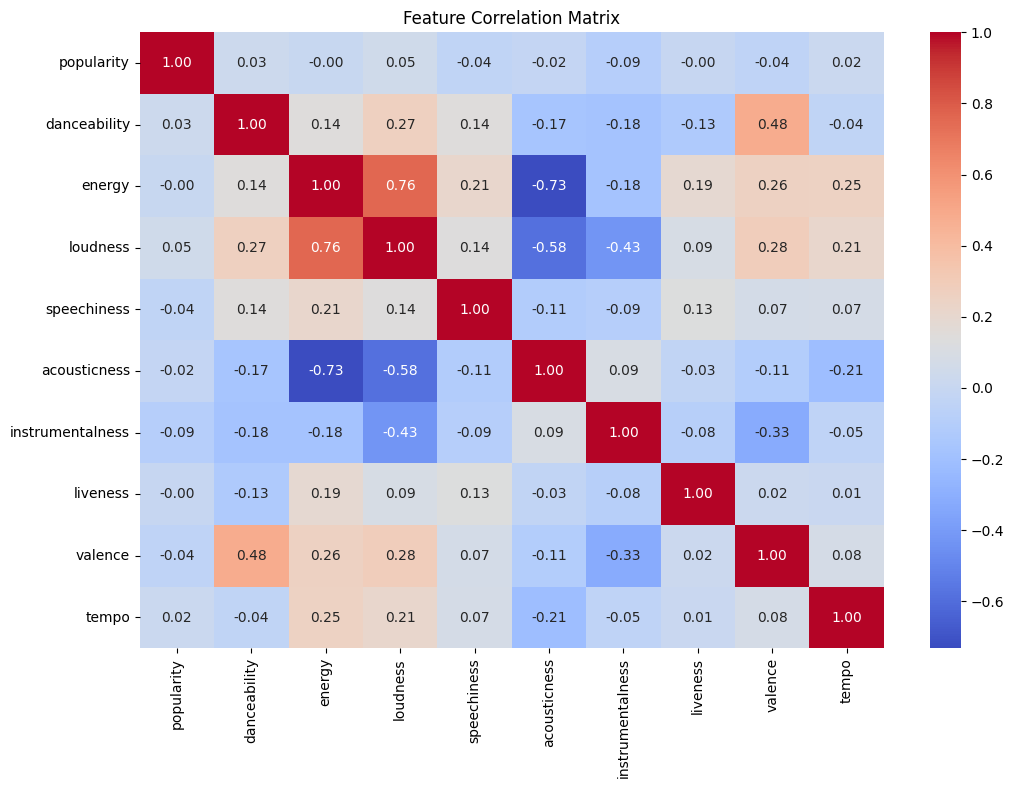

In [11]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_cleaned[features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

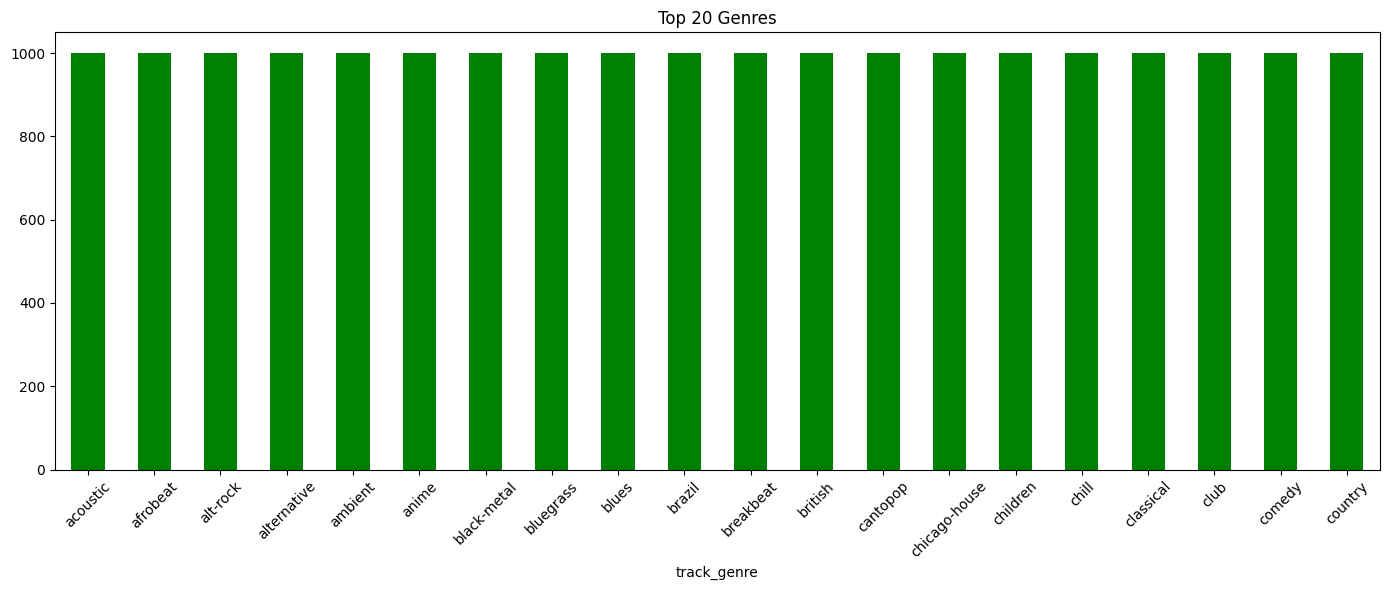

In [12]:
# Most popular genres
plt.figure(figsize=(14, 6))
df_cleaned['track_genre'].value_counts().head(20).plot(kind='bar', color='green')
plt.title('Top 20 Genres')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# I will use these features
features = ['popularity', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

# Normalizing ( sould be between 1-0)
scaler = MinMaxScaler()
df_scaled = df_cleaned.copy()
df_scaled[features] = scaler.fit_transform(df_cleaned[features])

print(df_scaled[features].head())

   popularity  danceability    energy  loudness  speechiness  acousticness  \
0    1.000000      0.820388  0.475748  0.918981     0.533582      0.033966   
1    0.797101      0.509709  0.171311  0.693687     0.284701      0.974684   
2    0.826087      0.531553  0.370485  0.854802     0.207836      0.221519   
3    1.000000      0.322816  0.061507  0.666194     0.135448      0.954641   
4    1.000000      0.750000  0.457172  0.855940     0.196269      0.494726   

   instrumentalness  liveness   valence     tempo  
0          0.000001  0.525698  0.784852  0.502190  
1          0.000006  0.148311  0.293085  0.442624  
2          0.000000  0.171806  0.131723  0.436015  
3          0.000078  0.193833  0.156970  1.000000  
4          0.000000  0.121733  0.183315  0.685159  
